### 1. Импорты, seed и устройство

In [1]:
import random
import json

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, ConcatDataset
from sklearn.metrics import precision_score, recall_score
import cv2

import torchvision
from torchvision import transforms as T
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

import albumentations as A
from albumentations.pytorch import ToTensorV2

# Фиксируем seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

In [2]:
# Определяем устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cpu


### 2. Часть A: Классификация STL10

#### 2.1 Загрузка данных

In [3]:
# Загрузка STL10
print("Загрузка STL10...")
stl10_train_split = torchvision.datasets.STL10(
    root='./stl10', split='train', download=True, transform=None
)
stl10_test_split = torchvision.datasets.STL10(
    root='./stl10', split='test', download=True, transform=None
)

# Объединяем train и test для полного датасета
stl10_full = ConcatDataset([stl10_train_split, stl10_test_split])
print(f"STL10 объединенный: {len(stl10_full)} изображений")

Загрузка STL10...
STL10 объединенный: 13000 изображений


In [4]:
# Разделение 80/10/10 с фиксированным seed
total_len = len(stl10_full)
train_len = int(total_len * 0.8)
val_len = int(total_len * 0.1)
test_len = total_len - train_len - val_len

generator = torch.Generator().manual_seed(SEED)
stl10_train_data, stl10_val_data, stl10_test_data = random_split(
    stl10_full, [train_len, val_len, test_len], generator=generator
)

print(f"Train: {len(stl10_train_data)} (80%)")
print(f"Val: {len(stl10_val_data)} (10%)")
print(f"Test: {len(stl10_test_data)} (10%)")

Train: 10400 (80%)
Val: 1300 (10%)
Test: 1300 (10%)


#### 2.2 Определение трансформаций

In [5]:
# Классы STL10
STL10_CLASSES = ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

# Трансформации через torchvision
basic_transform_tv = T.Compose([
    T.Resize((128, 128)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

aug_transform_tv = T.Compose([
    T.Resize((128, 128)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [6]:
# Создаем датасеты с трансформациями
class TransformDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# Для C1 (без аугментаций)
stl10_train_c1 = TransformDataset(stl10_train_data, basic_transform_tv)
# Для C2 (с аугментациями)
stl10_train_c2 = TransformDataset(stl10_train_data, aug_transform_tv)
# Для C3, C4 и валидации
stl10_train_resnet = TransformDataset(stl10_train_data, basic_transform_tv)
stl10_val = TransformDataset(stl10_val_data, basic_transform_tv)
stl10_test = TransformDataset(stl10_test_data, basic_transform_tv)

In [7]:
# DataLoader'ы
BATCH_SIZE = 16
NUM_WORKERS = 4

stl10_train_c1_loader = DataLoader(stl10_train_c1, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
stl10_train_c2_loader = DataLoader(stl10_train_c2, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
stl10_train_resnet_loader = DataLoader(stl10_train_resnet, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
stl10_val_loader = DataLoader(stl10_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
stl10_test_loader = DataLoader(stl10_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

#### 2.3 Визуализация аугментаций

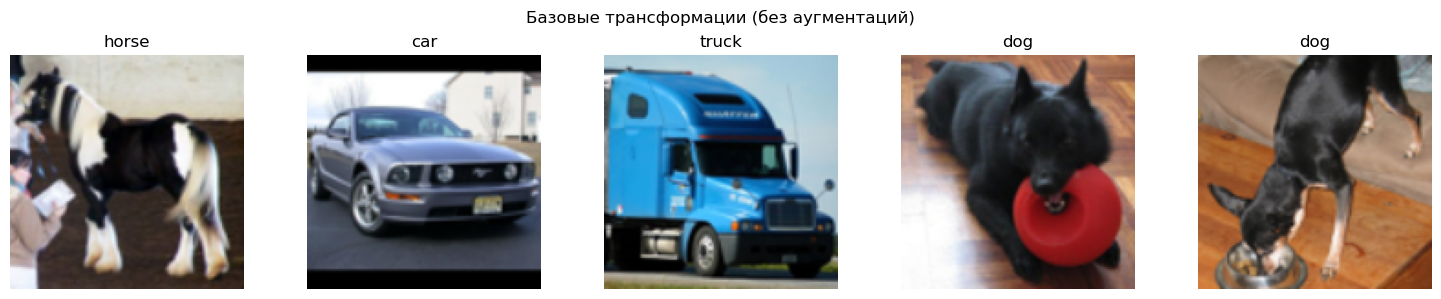

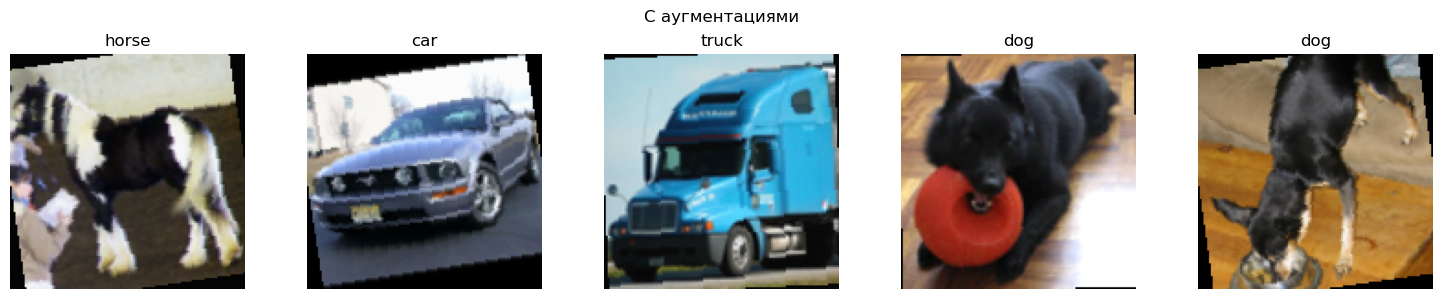

In [8]:
def visualize_augmentations(dataset, title, num_samples=5):
    """Визуализация примеров с аугментациями"""
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    
    for i in range(num_samples):
        img, label = dataset[i]
        # Денормализация
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img = img * std + mean
        img = torch.clamp(img, 0, 1)
        img = img.permute(1, 2, 0).numpy()
        
        axes[i].imshow(img)
        axes[i].set_title(f'{STL10_CLASSES[label]}')
        axes[i].axis('off')
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(f'artifacts/figures/augmentations_preview.png', dpi=150, bbox_inches='tight')
    plt.show()

# Визуализация
visualize_augmentations(stl10_train_c1, "Базовые трансформации (без аугментаций)", num_samples=5)
visualize_augmentations(stl10_train_c2, "С аугментациями", num_samples=5)

#### 2.4 Определение архитектур моделей

In [9]:
class SimpleCNN(nn.Module):
    """Простая CNN для C1 и C2"""
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [10]:
class ResNet18HeadOnly(nn.Module):
    """ResNet18 с замороженным backbone, обучается только голова"""
    def __init__(self, num_classes=10):
        super(ResNet18HeadOnly, self).__init__()
        self.backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        
        # Замораживаем backbone
        for param in self.backbone.parameters():
            param.requires_grad = False
        
        # Заменяем голову
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)
        self.fc = self.backbone.fc
    
    def forward(self, x):
        return self.backbone(x)

In [11]:
class ResNet18Finetune(nn.Module):
    """ResNet18 с fine-tune (разморожены layer4 и fc)"""
    def __init__(self, num_classes=10):
        super(ResNet18Finetune, self).__init__()
        self.backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        
        # Замораживаем все слои
        for param in self.backbone.parameters():
            param.requires_grad = False
        
        # Размораживаем layer4
        for param in self.backbone.layer4.parameters():
            param.requires_grad = True
        
        # Заменяем и размораживаем fc
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)
        self.fc = self.backbone.fc
    
    def forward(self, x):
        return self.backbone(x)

#### 2.5 Функции обучения и оценки

In [12]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Обучение одной эпохи"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(dataloader, desc='Training', leave=False):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    return running_loss / total, correct / total

In [13]:
def evaluate(model, dataloader, criterion, device):
    """Оценка модели"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Evaluating', leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return running_loss / total, correct / total

In [14]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, model_name, scheduler=None):
    """Полный цикл обучения"""
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'best_val_acc': 0.0
    }
    best_state = None
    
    for epoch in range(num_epochs):
        print(f"\n{model_name} - Epoch {epoch+1}/{num_epochs}")
        
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        
        if val_acc > history['best_val_acc']:
            history['best_val_acc'] = val_acc
            best_state = model.state_dict().copy()
            print(f"Новая лучшая модель! Val Acc: {val_acc:.4f}")
        
        if scheduler:
            scheduler.step(val_loss)
    
    model.load_state_dict(best_state)
    return model, history

#### 2.6 Эксперименты C1-C4

In [15]:
criterion = nn.CrossEntropyLoss()

NUM_EPOCHS = {
    'C1': 20,
    'C2': 20,
    'C3': 15,
    'C4': 15
}

models = {}
histories = {}
optimizers = {}
schedulers = {}
train_loaders = {
    'C1': stl10_train_c1_loader,
    'C2': stl10_train_c2_loader,
    'C3': stl10_train_resnet_loader,
    'C4': stl10_train_resnet_loader,
}

In [16]:
# C1: Simple CNN без аугментаций
print("="*60)
print("C1: Simple CNN без аугментаций")
print("="*60)
models['C1'] = SimpleCNN(num_classes=10).to(device)
optimizers['C1'] = optim.Adam(models['C1'].parameters(), lr=0.001)
schedulers['C1'] = optim.lr_scheduler.ReduceLROnPlateau(optimizers['C1'], mode='min', patience=3, factor=0.5)
models['C1'], histories['C1'] = train_model(
    models['C1'], train_loaders['C1'], stl10_val_loader, criterion,
    optimizers['C1'], NUM_EPOCHS['C1'], device, 'C1', schedulers['C1']
)

C1: Simple CNN без аугментаций

C1 - Epoch 1/20


Training:   0%|          | 0/650 [00:00<?, ?it/s]

Train Loss: 1.7031, Train Acc: 0.3390
Val Loss: 2.5476, Val Acc: 0.2515
Новая лучшая модель! Val Acc: 0.2515

C1 - Epoch 2/20


Train Loss: 1.4653, Train Acc: 0.4510
Val Loss: 1.5736, Val Acc: 0.4331
Новая лучшая модель! Val Acc: 0.4331

C1 - Epoch 3/20


Train Loss: 1.3428, Train Acc: 0.4967
Val Loss: 1.3409, Val Acc: 0.4908
Новая лучшая модель! Val Acc: 0.4908

C1 - Epoch 4/20


...

Train Loss: 0.8385, Train Acc: 0.7041
Val Loss: 0.8617, Val Acc: 0.6831

C1 - Epoch 17/20


Train Loss: 0.8231, Train Acc: 0.7070
Val Loss: 0.8641, Val Acc: 0.6885
Новая лучшая модель! Val Acc: 0.6885

C1 - Epoch 18/20


Train Loss: 0.7943, Train Acc: 0.7185
Val Loss: 0.9913, Val Acc: 0.6508

C1 - Epoch 19/20


Train Loss: 0.7600, Train Acc: 0.7284
Val Loss: 0.9378, Val Acc: 0.6731

C1 - Epoch 20/20


Train Loss: 0.7454, Train Acc: 0.7376
Val Loss: 0.9689, Val Acc: 0.6623


In [17]:
# C2: Simple CNN с аугментациями
print("\n" + "="*60)
print("C2: Simple CNN с аугментациями")
print("="*60)
models['C2'] = SimpleCNN(num_classes=10).to(device)
optimizers['C2'] = optim.Adam(models['C2'].parameters(), lr=0.001)
schedulers['C2'] = optim.lr_scheduler.ReduceLROnPlateau(optimizers['C2'], mode='min', patience=3, factor=0.5)
models['C2'], histories['C2'] = train_model(
    models['C2'], train_loaders['C2'], stl10_val_loader, criterion,
    optimizers['C2'], NUM_EPOCHS['C2'], device, 'C2', schedulers['C2']
)


C2: Simple CNN с аугментациями

C2 - Epoch 1/20


Train Loss: 1.7294, Train Acc: 0.3306
Val Loss: 1.6393, Val Acc: 0.3900
Новая лучшая модель! Val Acc: 0.3900

C2 - Epoch 2/20


Train Loss: 1.4988, Train Acc: 0.4312
Val Loss: 1.4200, Val Acc: 0.4538
Новая лучшая модель! Val Acc: 0.4538

C2 - Epoch 3/20


Train Loss: 1.3972, Train Acc: 0.4723
Val Loss: 1.3013, Val Acc: 0.5123
Новая лучшая модель! Val Acc: 0.5123

C2 - Epoch 4/20


Train Loss: 1.3320, Train Acc: 0.5051
Val Loss: 1.2395, Val Acc: 0.5315
Новая лучшая модель! Val Acc: 0.5315

C2 - Epoch 5/20


...

Train Loss: 0.9894, Train Acc: 0.6452
Val Loss: 0.9446, Val Acc: 0.6600
Новая лучшая модель! Val Acc: 0.6600

C2 - Epoch 17/20


Train Loss: 0.9794, Train Acc: 0.6492
Val Loss: 0.9972, Val Acc: 0.6408

C2 - Epoch 18/20


Train Loss: 0.9604, Train Acc: 0.6537
Val Loss: 0.8796, Val Acc: 0.6862
Новая лучшая модель! Val Acc: 0.6862

C2 - Epoch 19/20


Train Loss: 0.9321, Train Acc: 0.6631
Val Loss: 0.9165, Val Acc: 0.6838

C2 - Epoch 20/20


Train Loss: 0.9298, Train Acc: 0.6687
Val Loss: 0.9132, Val Acc: 0.6562


In [18]:
# C3: ResNet18 Head Only
print("\n" + "="*60)
print("C3: ResNet18 Head Only (замороженный backbone)")
print("="*60)
models['C3'] = ResNet18HeadOnly(num_classes=10).to(device)
optimizers['C3'] = optim.Adam(models['C3'].fc.parameters(), lr=0.01)
schedulers['C3'] = optim.lr_scheduler.ReduceLROnPlateau(optimizers['C3'], mode='min', patience=3, factor=0.5)
models['C3'], histories['C3'] = train_model(
    models['C3'], train_loaders['C3'], stl10_val_loader, criterion,
    optimizers['C3'], NUM_EPOCHS['C3'], device, 'C3', schedulers['C3']
)


C3: ResNet18 Head Only (замороженный backbone)

C3 - Epoch 1/15


Train Loss: 1.0355, Train Acc: 0.7690
Val Loss: 0.9918, Val Acc: 0.8200
Новая лучшая модель! Val Acc: 0.8200

C3 - Epoch 2/15


Train Loss: 1.0522, Train Acc: 0.8091
Val Loss: 1.1113, Val Acc: 0.8431
Новая лучшая модель! Val Acc: 0.8431

C3 - Epoch 3/15


Train Loss: 1.1302, Train Acc: 0.8155
Val Loss: 0.9767, Val Acc: 0.8615
Новая лучшая модель! Val Acc: 0.8615

C3 - Epoch 4/15


Train Loss: 1.1356, Train Acc: 0.8273
Val Loss: 0.9956, Val Acc: 0.8592

C3 - Epoch 5/15


...

Train Loss: 0.7512, Train Acc: 0.8562
Val Loss: 0.9654, Val Acc: 0.8685

C3 - Epoch 12/15


Train Loss: 0.7182, Train Acc: 0.8582
Val Loss: 0.8974, Val Acc: 0.8638

C3 - Epoch 13/15


Train Loss: 0.7533, Train Acc: 0.8562
Val Loss: 0.8684, Val Acc: 0.8715

C3 - Epoch 14/15


Train Loss: 0.5760, Train Acc: 0.8743
Val Loss: 0.7004, Val Acc: 0.8762
Новая лучшая модель! Val Acc: 0.8762

C3 - Epoch 15/15


Train Loss: 0.5496, Train Acc: 0.8726
Val Loss: 0.7286, Val Acc: 0.8800
Новая лучшая модель! Val Acc: 0.8800


In [19]:
# C4: ResNet18 Fine-tune
print("\n" + "="*60)
print("C4: ResNet18 Fine-tune (layer4 + fc разморожены)")
print("="*60)
models['C4'] = ResNet18Finetune(num_classes=10).to(device)
optimizers['C4'] = optim.Adam([
    {'params': models['C4'].backbone.layer4.parameters(), 'lr': 0.0001},
    {'params': models['C4'].backbone.fc.parameters(), 'lr': 0.001}
])
schedulers['C4'] = optim.lr_scheduler.ReduceLROnPlateau(optimizers['C4'], mode='min', patience=3, factor=0.5)
models['C4'], histories['C4'] = train_model(
    models['C4'], train_loaders['C4'], stl10_val_loader, criterion,
    optimizers['C4'], NUM_EPOCHS['C4'], device, 'C4', schedulers['C4']
)


C4: ResNet18 Fine-tune (layer4 + fc разморожены)

C4 - Epoch 1/15


Train Loss: 0.4720, Train Acc: 0.8399
Val Loss: 0.3371, Val Acc: 0.9085
Новая лучшая модель! Val Acc: 0.9085

C4 - Epoch 2/15


Train Loss: 0.1640, Train Acc: 0.9440
Val Loss: 0.2717, Val Acc: 0.9138
Новая лучшая модель! Val Acc: 0.9138

C4 - Epoch 3/15


Train Loss: 0.0988, Train Acc: 0.9646
Val Loss: 0.3346, Val Acc: 0.9154
Новая лучшая модель! Val Acc: 0.9154

C4 - Epoch 4/15


Train Loss: 0.0725, Train Acc: 0.9757
Val Loss: 0.3750, Val Acc: 0.9131

C4 - Epoch 5/15


...

Train Loss: 0.0091, Train Acc: 0.9974
Val Loss: 0.3362, Val Acc: 0.9269

C4 - Epoch 12/15


Train Loss: 0.0077, Train Acc: 0.9976
Val Loss: 0.3437, Val Acc: 0.9246

C4 - Epoch 13/15


Train Loss: 0.0043, Train Acc: 0.9988
Val Loss: 0.3517, Val Acc: 0.9215

C4 - Epoch 14/15


Train Loss: 0.0073, Train Acc: 0.9979
Val Loss: 0.3519, Val Acc: 0.9285
Новая лучшая модель! Val Acc: 0.9285

C4 - Epoch 15/15


Train Loss: 0.0055, Train Acc: 0.9984
Val Loss: 0.3280, Val Acc: 0.9300
Новая лучшая модель! Val Acc: 0.9300


#### 2.7 Сравнение моделей и выбор лучшей

In [20]:
# Сравнение validation accuracy
comparison = []
for key in ['C1', 'C2', 'C3', 'C4']:
    best_val = histories[key]['best_val_acc']
    comparison.append((key, best_val))
    print(f"{key}: Best Val Accuracy = {best_val:.4f}")

best_model_name, best_val_acc = max(comparison, key=lambda x: x[1])
print(f"\nЛучшая модель: {best_model_name} с {best_val_acc:.4f}")

C1: Best Val Accuracy = 0.6885
C2: Best Val Accuracy = 0.6862
C3: Best Val Accuracy = 0.8800
C4: Best Val Accuracy = 0.9300

Лучшая модель: C4 с 0.9300


In [21]:
# Финальная оценка на тесте
test_loss, test_acc = evaluate(models[best_model_name], stl10_test_loader, criterion, device)
print(f"\nФинальная оценка лучшей модели ({best_model_name}) на тесте:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Финальная оценка лучшей модели (C4) на тесте:
Test Loss: 0.3235
Test Accuracy: 0.9423


#### 2.8 Визуализация результатов классификации

In [22]:
def plot_training_history(history, model_name):
    """График обучения"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history['train_loss']) + 1)
    
    ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    ax1.plot(epochs, history['val_loss'], 'r-', label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{model_name} - Loss')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(epochs, history['train_acc'], 'b-', label='Train Acc')
    ax2.plot(epochs, history['val_acc'], 'r-', label='Val Acc')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{model_name} - Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    return fig

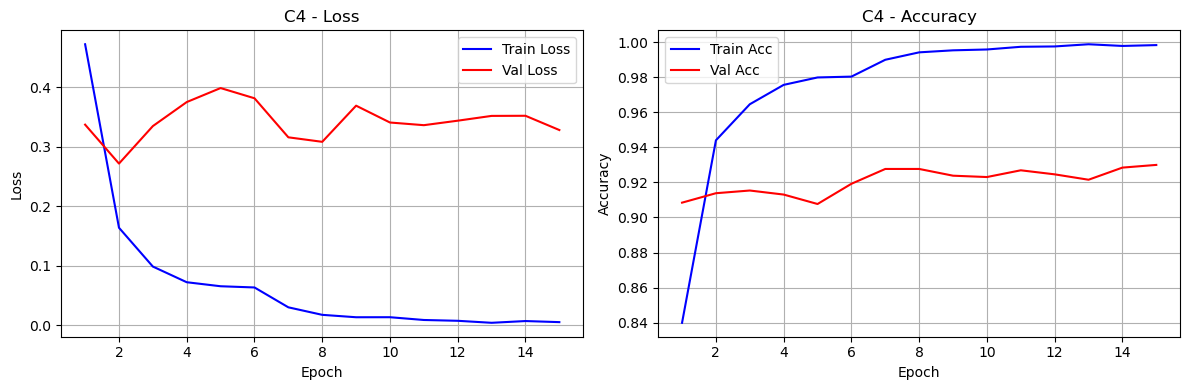

In [23]:
# График для лучшей модели
fig = plot_training_history(histories[best_model_name], best_model_name)
plt.savefig('artifacts/figures/classification_curves_best.png', dpi=150, bbox_inches='tight')
plt.show()

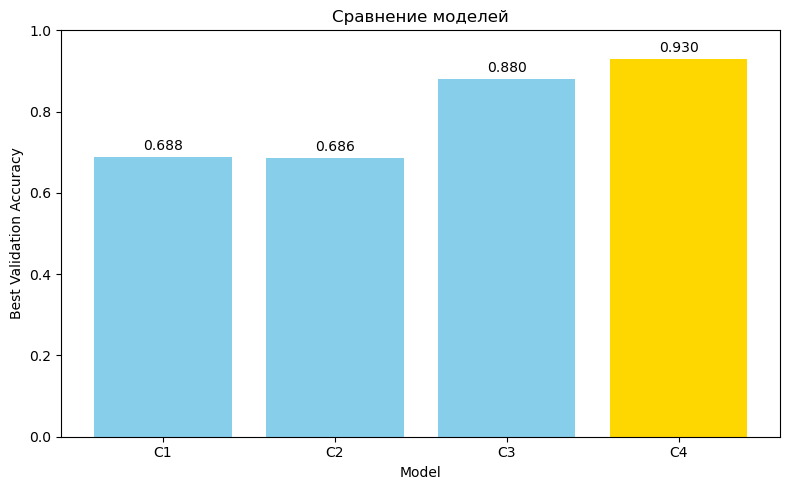

In [24]:
# Сравнение всех моделей
fig, ax = plt.subplots(figsize=(8, 5))
model_names = [c[0] for c in comparison]
val_scores = [c[1] for c in comparison]
colors = ['gold' if name == best_model_name else 'skyblue' for name in model_names]
bars = ax.bar(model_names, val_scores, color=colors)
ax.set_xlabel('Model')
ax.set_ylabel('Best Validation Accuracy')
ax.set_title('Сравнение моделей')
ax.set_ylim([0, 1])

for bar, score in zip(bars, val_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{score:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('artifacts/figures/classification_compare.png', dpi=150, bbox_inches='tight')
plt.show()

#### 2.9 Сохранение лучшей модели и конфига

In [ ]:
# Сохраняем модель
torch.save(models[best_model_name].state_dict(), 'artifacts/best_classifier.pt')

# Сохраняем конфиг
config = {
    'seed': SEED,
    'best_model': best_model_name,
    'dataset': {'name': 'STL10', 'classes': 10, 'split': {'train': 10400, 'val': 1300, 'test': 1300}},
    'model': {
        'architecture': models[best_model_name].__class__.__name__,
        'pretrained': best_model_name in ['C3', 'C4'],
        'trainable_layers': {'C1': 'all', 'C2': 'all', 'C3': 'fc_only', 'C4': 'layer4+fc'}.get(best_model_name, 'all')
    },
    'transforms': 'basic' if best_model_name != 'C2' else 'augmented',
    'training': {
        'batch_size': BATCH_SIZE,
        'epochs': NUM_EPOCHS[best_model_name],
        'optimizer': 'Adam',
        'loss': 'CrossEntropyLoss'
    },
    'results': {
        'best_val_acc': best_val_acc,
        'test_acc': test_acc
    }
}

with open('artifacts/best_classifier_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("✅ Лучшая модель и конфиг сохранены")

✅ Лучшая модель и конфиг сохранены


### 3. Часть B: Сегментация SBDataset

In [3]:
sbd_full = torchvision.datasets.SBDataset(
    root='./sbd',
    image_set='train_noval',   # исключаем изображения из VOC2012 val во избежание утечки данных
    mode='segmentation',
    download=False,
    transforms=None
)
print(f"SBDataset загружен: {len(sbd_full)} изображений")

# Разделение 80/10/10
total_sbd = len(sbd_full)
train_sbd = int(total_sbd * 0.8)
val_sbd = int(total_sbd * 0.1)
test_sbd = total_sbd - train_sbd - val_sbd

generator = torch.Generator().manual_seed(SEED)
sbd_train, sbd_val, sbd_test = random_split(sbd_full, [train_sbd, val_sbd, test_sbd], generator=generator)
print(f"SBDataset - Train: {train_sbd}, Val: {val_sbd}, Test: {test_sbd}")


SBDataset загружен: 5623 изображений
SBDataset - Train: 4498, Val: 562, Test: 563


In [4]:
FOREGROUND_CLASS = 15

In [5]:
def get_binary_metrics(pred, true):
    """
    Вычисление IoU, Precision и Recall для бинарной маски (foreground vs background)
    """
    pred_flat = pred.flatten()
    true_flat = true.flatten()
    
    # Intersection over Union
    intersection = np.logical_and(pred, true).sum()
    union = np.logical_or(pred, true).sum()
    iou = intersection / union if union > 0 else 0.0
    
    # Pixel-wise Precision & Recall
    precision = precision_score(true_flat, pred_flat, zero_division=0)
    recall = recall_score(true_flat, pred_flat, zero_division=0)
    
    return iou, precision, recall

In [6]:
def get_segmentation_transform(img_size=(224, 224)):
    """
    Трансформации: 
    - Ресайз маски БЕЗ интерполяции (Nearest)
    - Стандартная нормализация ImageNet
    """
    return A.Compose([
        A.Resize(height=img_size[0], width=img_size[1], interpolation=cv2.INTER_LINEAR),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ], 
    # Это гарантирует, что маска ресайзится через INTER_NEAREST автоматически
    additional_targets={'mask': 'mask'} 
    )

# Определяем transform
seg_transform = get_segmentation_transform((224, 224))

In [7]:
class SegmentationDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform
        self.target_class = FOREGROUND_CLASS # Person

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, mask = self.dataset[idx]
        img = np.array(img) # Оставляем 0-255 для Albumentations
        mask = np.array(mask)
        
        # Строгая бинаризация: ТОЛЬКО класс 15 становится 1, всё остальное (и 255) -> 0
        binary_mask = (mask == self.target_class).astype(np.float32)
        
        if self.transform:
            augmented = self.transform(image=img, mask=binary_mask)
            img = augmented['image']
            mask = augmented['mask'].long() # Возвращаем как long для CrossEntropy или IoU
            
        return img, mask

# Создаем датасеты
sbd_train_dataset = SegmentationDataset(sbd_train, seg_transform)
sbd_val_dataset = SegmentationDataset(sbd_val, seg_transform)
sbd_test_dataset = SegmentationDataset(sbd_test, seg_transform)

In [8]:
# DataLoader'ы
sbd_train_loader = DataLoader(sbd_train_dataset, batch_size=32, shuffle=True, num_workers=4)
sbd_val_loader = DataLoader(sbd_val_dataset, batch_size=32, shuffle=False, num_workers=4)
sbd_test_loader = DataLoader(sbd_test_dataset, batch_size=32, shuffle=False, num_workers=4)

#### 3.3 Загрузка предобученной модели сегментации

In [9]:
# Загружаем DeepLabV3 с предобученными весами
weights = DeepLabV3_ResNet50_Weights.DEFAULT
seg_model = deeplabv3_resnet50(weights=weights).to(device)
seg_model.eval()

DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

#### 3.4 Функции для визуализации и метрик

In [10]:
def compute_iou(pred_mask, true_mask, num_classes=21):
    """Вычисление IoU для каждого класса"""
    ious = []
    for cls in range(num_classes):
        pred = (pred_mask == cls)
        true = (true_mask == cls)
        intersection = (pred & true).sum().float()
        union = (pred | true).sum().float()
        if union > 0:
            ious.append((intersection / union).item())
        else:
            ious.append(float('nan'))
    return ious

In [11]:
def mean_iou(pred_mask, true_mask, num_classes=2):
    """Средний IoU (игнорируя фон)"""
    ious = []
    for cls in range(num_classes):
        pred = (pred_mask == cls)
        true = (true_mask == cls)
        intersection = np.logical_and(pred, true).sum()
        union = np.logical_or(pred, true).sum()
        if union > 0:
            ious.append(intersection / union)
        else:
            ious.append(float('nan'))
    # Исключаем фон (класс 0) если нужно
    valid_ious = [iou for iou in ious[1:] if not np.isnan(iou)]
    return np.mean(valid_ious) if valid_ious else 0 

In [ ]:
def postprocess_mask(mask_logits, threshold=0.5, min_size=100):
    """Постобработка маски: бинаризация + удаление маленьких компонент"""
    # Бинаризация
    binary_mask = (torch.sigmoid(mask_logits) > threshold).float()
    
    # Удаление маленьких компонент (только для CPU)
    if min_size > 0:
        from scipy import ndimage
        mask_np = binary_mask.cpu().numpy().astype(np.uint8)
        labeled, num_features = ndimage.label(mask_np)
        sizes = ndimage.sum(mask_np, labeled, range(num_features + 1))
        mask_clean = np.zeros_like(mask_np)
        for i in range(1, num_features + 1):
            if sizes[i] >= min_size:
                mask_clean[labeled == i] = 1
        binary_mask = torch.from_numpy(mask_clean).to(mask_logits.device)
    
    return binary_mask.long()

In [ ]:
def denormalize(img_tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """Инверсия нормализации ImageNet для визуализации"""
    if torch.is_tensor(img_tensor):
        img = img_tensor.permute(1, 2, 0).cpu().numpy()
    else:
        img = img_tensor
        
    img = img * std + mean
    return np.clip(img, 0, 1)

In [ ]:
def visualize_segmentation(images, masks_pred, masks_true, num_samples=3, save_path=None):
    """
    Визуализация: выбирает из предложенных данных только те, где есть объект (люди).
    """
    voc_palette = np.array([
        [0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0], [0, 0, 128],
        [128, 0, 128], [0, 128, 128], [128, 128, 128], [64, 0, 0], [192, 0, 0],
        [64, 128, 0], [192, 128, 0], [64, 0, 128], [192, 0, 128], [64, 128, 128],
        [192, 128, 128], [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0], [0, 64, 128]
    ])

    valid_indices = []
    for idx in range(len(masks_true)):
        m = masks_true[idx]
        if torch.is_tensor(m):
            m = m.cpu().numpy()
        if np.sum(m) > 0:  # Если есть хотя бы один пиксель человека
            valid_indices.append(idx)
    
    display_indices = valid_indices[:num_samples]
    actual_num = len(display_indices)
    
    if actual_num == 0:
        print("В переданной выборке не найдено изображений с людьми.")
        return

    fig, axes = plt.subplots(actual_num, 3, figsize=(15, 5 * actual_num))
    if actual_num == 1:
        axes = axes.reshape(1, -1)
    
    for i, idx in enumerate(display_indices):
        # Изображение с денормализацией
        img_display = denormalize(images[idx])
        
        # Маски
        def to_numpy_mask(m):
            if torch.is_tensor(m): m = m.cpu().numpy()
            return np.clip(m.astype(np.int64), 0, 20)

        pred_idx = to_numpy_mask(masks_pred[idx])
        true_idx = to_numpy_mask(masks_true[idx])
        
        pred_rgb = voc_palette[pred_idx]
        true_rgb = voc_palette[true_idx]
        
        # Отрисовка
        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title(f'Sample {idx} - Original')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(pred_rgb)
        axes[i, 1].set_title('Predicted Mask')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(true_rgb)
        axes[i, 2].set_title('Ground Truth (Person)')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

#### 3.5 Оценка модели с двумя режимами постобработки

In [ ]:
def evaluate_segmentation(model, loader, postprocess_fn, num_samples=3):
    """
    Оценка модели с сохранением примеров ТОЛЬКО тех изображений, 
    где присутствует TARGET_CLASS.
    """
    model.eval()
    metrics = {'iou': [], 'precision': [], 'recall': []}
    samples = []

    with torch.no_grad():
        for images, masks in tqdm(loader, desc='Evaluating & Filtering'):
            images = images.to(device)
            outputs = model(images)['out']
            target_logits = outputs[:, FOREGROUND_CLASS, :, :] 
            
            preds = postprocess_fn(target_logits)
            
            preds_cpu = preds.cpu().numpy()
            masks_cpu = masks.numpy().astype(np.uint8) 

            for j in range(images.size(0)):
                p = preds_cpu[j]
                t = masks_cpu[j]
                
                miou, prec, rec = get_binary_metrics(p, t)
                metrics['iou'].append(miou)
                metrics['precision'].append(prec)
                metrics['recall'].append(rec)
                
                if len(samples) < num_samples and t.sum() > 0:
                    samples.append((images[j].cpu(), p, t))

    if len(samples) < num_samples:
        print(f"Предупреждение: Найдено только {len(samples)} изображений с людьми.")

    return {k: np.mean(v) for k, v in metrics.items()}, samples

#### 3.6 Режим V1: базовая постобработка (threshold=0.5)


Режим V1: базовая постобработка (threshold=0.5)


Evaluating & Filtering: 100%|██████████| 18/18 [01:20<00:00,  4.45s/it]


Mean IoU:       0.0641
Mean Precision: 0.0641
Mean Recall:    0.3033


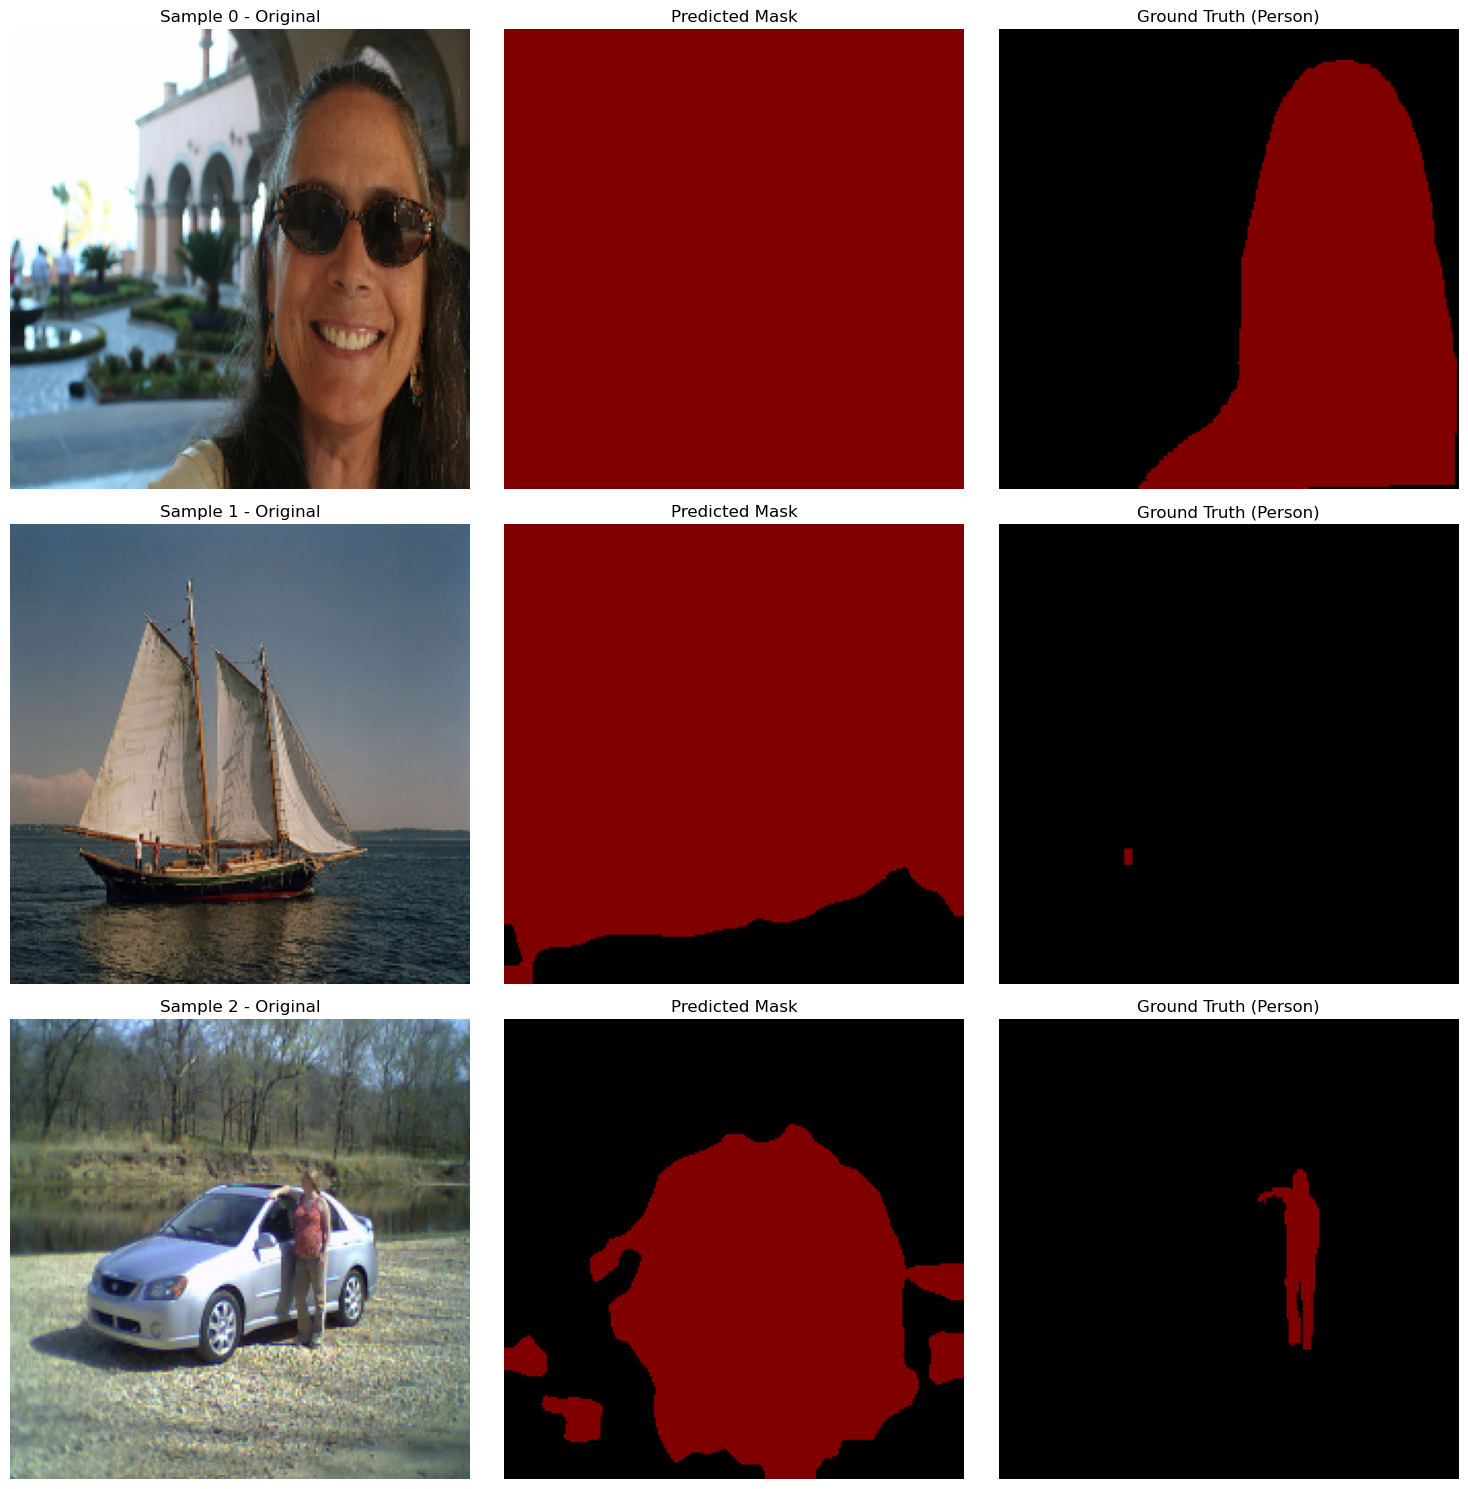

In [16]:
print("\n" + "="*60)
print("Режим V1: базовая постобработка (threshold=0.5)")
print("="*60)

def postprocess_v1(logits, threshold=0.5):
    """Базовая бинаризация"""
    probs = torch.sigmoid(logits)
    return (probs > threshold).long()

metrics_v1, samples_v1 = evaluate_segmentation(
    seg_model, sbd_val_loader, postprocess_v1,
)
images_v1, preds_v1, trues_v1 = zip(*samples_v1)

print(f"Mean IoU:       {metrics_v1['iou']:.4f}")
print(f"Mean Precision: {metrics_v1['precision']:.4f}")
print(f"Mean Recall:    {metrics_v1['recall']:.4f}")

# Визуализация
visualize_segmentation(images_v1, preds_v1, trues_v1, num_samples=3,
                       save_path='artifacts/figures/segmentation_examples.png')

 #### 3.7 Режим V2: альтернативная постобработка (threshold=0.7 + удаление маленьких компонент)


Режим V2: альтернативная постобработка (threshold=0.7 + удаление маленьких компонент)


Evaluating & Filtering: 100%|██████████| 18/18 [01:15<00:00,  4.20s/it]


Mean IoU:       0.0648
Mean Precision: 0.0648
Mean Recall:    0.3027


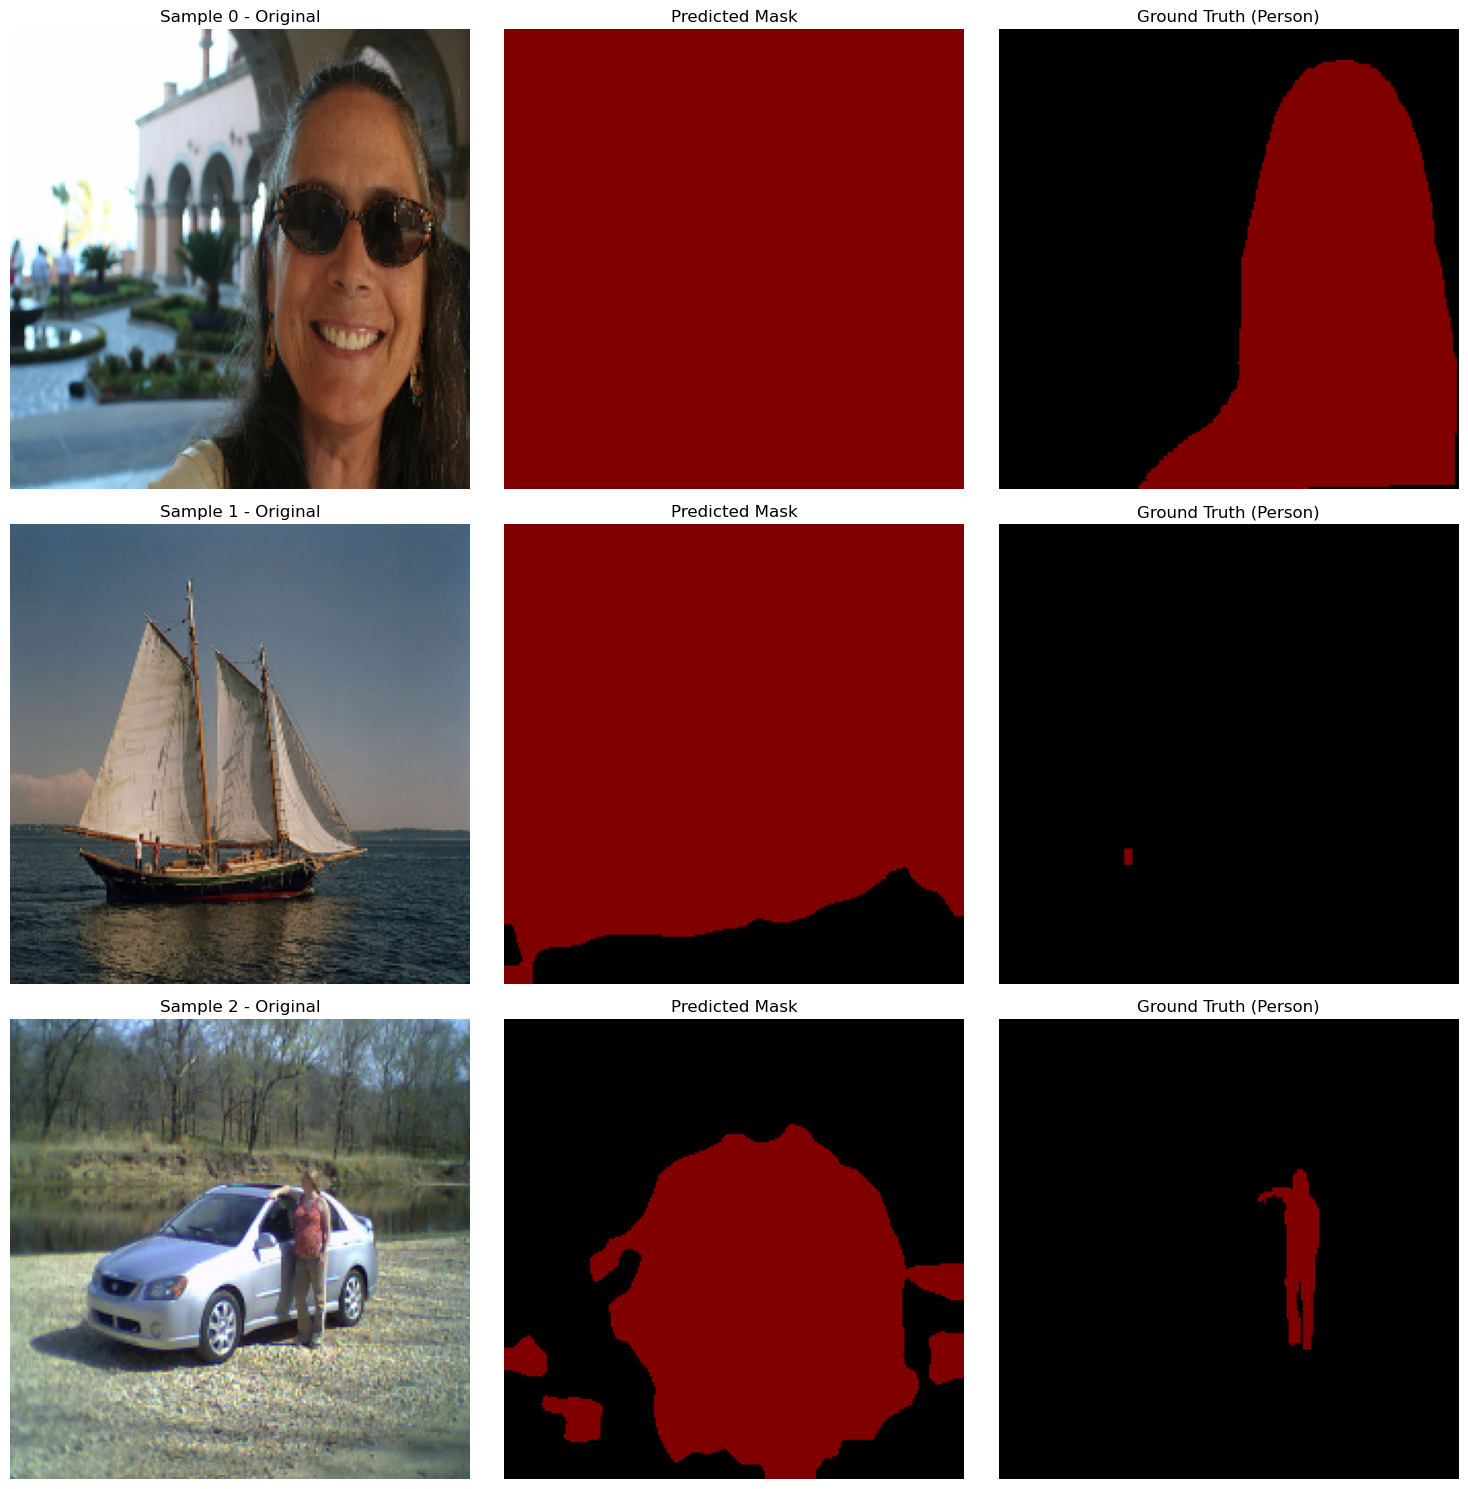

In [17]:
print("\n" + "="*60)
print("Режим V2: альтернативная постобработка (threshold=0.7 + удаление маленьких компонент)")
print("="*60)

def postprocess_v2(logits, threshold=0.6, min_size=150):
    """
    Альтернативная постобработка с корректной обработкой батча для OpenCV
    """
    probs = torch.sigmoid(logits)
    # Переносим в numpy [B, H, W]
    masks_np = (probs > threshold).cpu().numpy().astype(np.uint8)
    
    clean_masks = []
    
    # Итерируемся по каждому изображению в батче
    for i in range(masks_np.shape[0]):
        mask = masks_np[i]
        
        # Находим связные компоненты
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
        
        clean_mask = np.zeros_like(mask)
        # Пропускаем индекс 0 (это фон)
        for j in range(1, num_labels):
            if stats[j, cv2.CC_STAT_AREA] >= min_size:
                clean_mask[labels == j] = 1
        
        clean_masks.append(clean_mask)
    
    # Собираем обратно в тензор и возвращаем на устройство
    return torch.from_numpy(np.array(clean_masks)).to(logits.device).long()

metrics_v2, samples_v2 = evaluate_segmentation(
    seg_model, sbd_val_loader, postprocess_v2,
)
images_v2, preds_v2, trues_v2 = zip(*samples_v1)

print(f"Mean IoU:       {metrics_v2['iou']:.4f}")
print(f"Mean Precision: {metrics_v2['precision']:.4f}")
print(f"Mean Recall:    {metrics_v2['recall']:.4f}")

# Визуализация
visualize_segmentation(images_v2, preds_v2, trues_v2, num_samples=3)

#### 3.8 Сравнение режимов

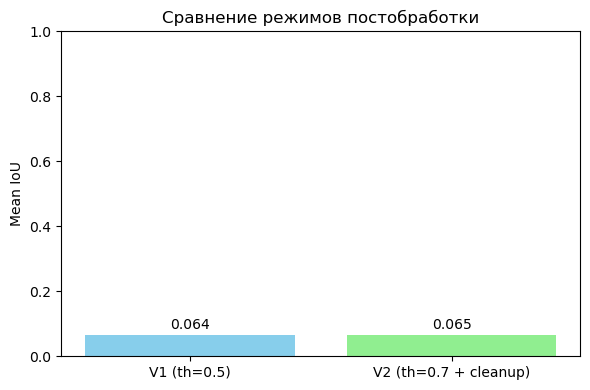


Результаты:
V1 (threshold=0.5): Mean IoU = 0.0641
V2 (threshold=0.7 + cleanup): Mean IoU = 0.0648
Разница: 0.0007


In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['V1 (th=0.5)', 'V2 (th=0.7 + cleanup)'], [metrics_v1['iou'], metrics_v2['iou']], color=['skyblue', 'lightgreen'])
ax.set_ylabel('Mean IoU')
ax.set_title('Сравнение режимов постобработки')
ax.set_ylim([0, 1])

for bar, val in zip(bars, [metrics_v1['iou'], metrics_v2['iou']]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('artifacts/figures/segmentation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nРезультаты:")
print(f"V1 (threshold=0.5): Mean IoU = {metrics_v1['iou']:.4f}")
print(f"V2 (threshold=0.7 + cleanup): Mean IoU = {metrics_v2['iou']:.4f}")
print(f"Разница: {metrics_v2['iou'] - metrics_v1['iou']:.4f}")

### 4. Сохранение результатов в runs.csv

In [ ]:
import pandas as pd

# Собираем результаты
results = []

# Часть A
for key in ['C1', 'C2', 'C3', 'C4']:
    results.append({
        'experiment_id': key,
        'task': 'classification',
        'dataset': 'STL10',
        'seed': SEED,
        'model_summary': models[key].__class__.__name__,
        'optimizer': 'Adam',
        'lr': 0.001, #if key in ['C1', 'C2'] else (0.01 if key == 'C3' else 'layer4:0.0001, fc:0.001'),
        'epochs_trained': NUM_EPOCHS[key],
        'best_val_accuracy': histories[key]['best_val_acc'],
        'test_accuracy': test_acc if key == best_model_name else None,
        'precision': None,
        'recall': None,
        'mean_iou': None,
        'notes': None
    })

# Часть B
results.append({
    'experiment_id': 'V1',
    'task': 'segmentation',
    'dataset': 'SBDataset',
    'seed': SEED,
    'model_summary': 'DeepLabV3_ResNet50',
    'optimizer': None,
    'lr': None,
    'epochs_trained': None,
    'best_val_accuracy': None,
    'test_accuracy': None,
    'precision': None,
    'recall': None,
    'mean_iou': metrics_v1['iou'],
    'notes': 'threshold=0.5'
})

results.append({
    'experiment_id': 'V2',
    'task': 'segmentation',
    'dataset': 'SBDataset',
    'seed': SEED,
    'model_summary': 'DeepLabV3_ResNet50',
    'optimizer': None,
    'lr': None,
    'epochs_trained': None,
    'best_val_accuracy': None,
    'test_accuracy': None,
    'precision': None,
    'recall': None,
    'mean_iou': metrics_v2['iou'],
    'notes': 'threshold=0.7 + min_size=100'
})

# Сохраняем
df = pd.DataFrame(results)
df.to_csv('artifacts/runs.csv', index=False)
print("\nРезультаты сохранены в artifacts/runs.csv")
print(df)


Результаты сохранены в artifacts/runs.csv
  experiment_id            task    dataset  seed       model_summary  \
0            C1  classification      STL10    42           SimpleCNN   
1            C2  classification      STL10    42           SimpleCNN   
2            C3  classification      STL10    42    ResNet18HeadOnly   
3            C4  classification      STL10    42    ResNet18Finetune   
4            V1    segmentation  SBDataset    42  DeepLabV3_ResNet50   
5            V2    segmentation  SBDataset    42  DeepLabV3_ResNet50   

  optimizer                       lr  epochs_trained  best_val_accuracy  \
0      Adam                    0.001            20.0           0.688462   
1      Adam                    0.001            20.0           0.686154   
2      Adam                     0.01            15.0           0.880000   
3      Adam  layer4:0.0001, fc:0.001            15.0           0.930000   
4      None                     None             NaN                NaN   
5 